# First understand the structure

Ask these questions first:

How many rows do I have?

Are CLIENT_IDs unique?

Are there missing values?

Are the data types correct?

CLIENT_ID should usually be unique.

CLIENT_CREATE DATE should be converted to datetime.

REGION may have missing values. The roadmap says about 2.1% are missing.

In [ ]:
#eE
import pandas as pd

# Load CSV file
df = pd.read_csv("../TOOL_CLIENT.csv")

# Show first rows
print(f"number of rows: {len(df)}")

if df["CLIENT_ID"].is_unique:
    print("All CLIENT_ID values are unique")
else:
    print("There are duplicates")
    


number of rows: 93257
All values are unique


Missing values

In [4]:
#eE
for col in df.columns:
    missing_count = df[col].isna().sum()
    print(f"{col}: {missing_count} missing values")

CLIENT_ID: 0 missing values
CLIENT_CREATE DATE: 0 missing values
REGION: 1981 missing values
TRADE SECTOR: 0 missing values
N_EMPLOYEES: 0 missing values
ECONOMIC_POT: 0 missing values
ECO_POT_CLASS: 0 missing values
RISK_CAT: 0 missing values


#  Explore each variable one by one

When were most clients created?

<Axes: xlabel='create_year'>

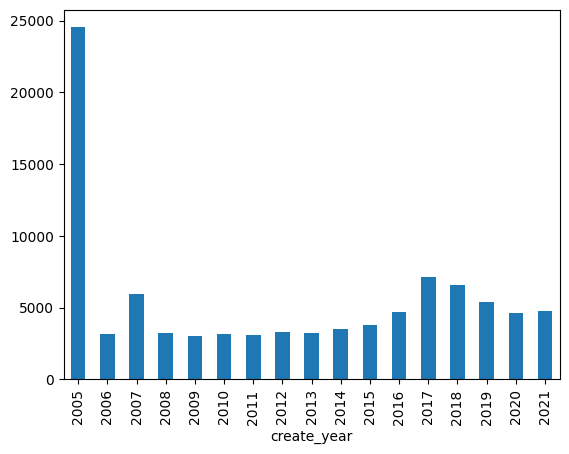

In [5]:
df["CLIENT_CREATE DATE"] = pd.to_datetime(df["CLIENT_CREATE DATE"], errors="coerce")
df["create_year"] = df["CLIENT_CREATE DATE"].dt.year
df["create_month"] = df["CLIENT_CREATE DATE"].dt.month

df["create_year"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='create_month'>

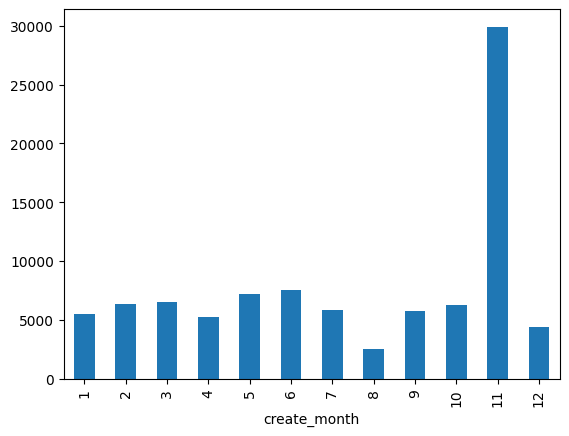

In [6]:
df["create_month"].value_counts().sort_index().plot(kind="bar")

Plottiing a month from a spcific yar

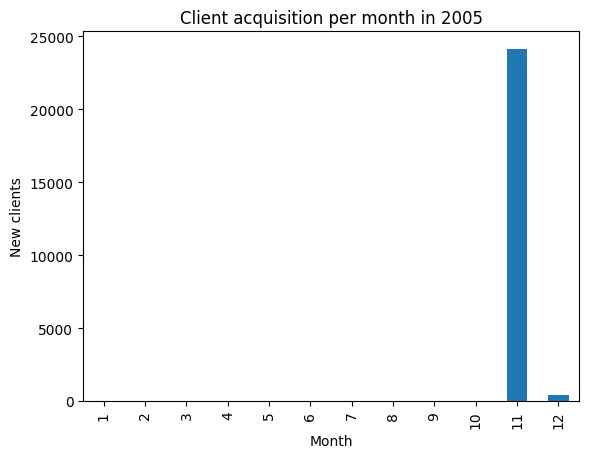

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df["CLIENT_CREATE DATE"] = pd.to_datetime(df["CLIENT_CREATE DATE"], errors="coerce")

year = 2005

monthly_acq = (
    df[df["CLIENT_CREATE DATE"].dt.year == year]
    .groupby(df["CLIENT_CREATE DATE"].dt.month)
    .size()
    .reindex(range(1, 13), fill_value=0)
)

monthly_acq.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("New clients")
plt.title(f"Client acquisition per month in {year}")
plt.show()

Are registrations growing or declining over time?

<Axes: xlabel='CLIENT_CREATE DATE'>

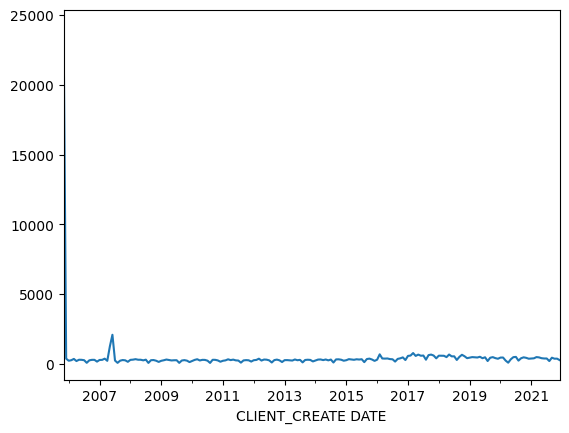

In [33]:
df["CLIENT_CREATE DATE"] = pd.to_datetime(df["CLIENT_CREATE DATE"], errors="coerce")

registrations = (
    df.set_index("CLIENT_CREATE DATE")
      .resample("ME")
      .size()
)

registrations.plot()

Center: what is a “typical” client?

mean = average

median = middle value

Why both matter:

If the mean and median are close, the distribution is fairly balanced.

If the mean is much larger than the median, a few very large clients are pulling the average up.

Spread: how much do clients differ?

Skewness: is the distribution lopsided?


most clients have low employee counts or low economic potential

a small number of clients are much larger or more valuable

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["N_EMPLOYEES", "ECONOMIC_POT"]

# Make sure the columns are numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Summary stats + skewness + outliers
summary = []

for col in cols:
    s = df[col].dropna()

    mean_ = s.mean()
    median_ = s.median()
    min_ = s.min()
    max_ = s.max()
    std_ = s.std()
    skew_ = s.skew()

    # IQR method for outliers
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = s[(s < lower_bound) | (s > upper_bound)]

    summary.append({
        "column": col,
        "count": s.count(),
        "mean": mean_,
        "median": median_,
        "min": min_,
        "max": max_,
        "std": std_,
        "skewness": skew_,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_outlier_bound": lower_bound,
        "upper_outlier_bound": upper_bound,
        "n_outliers": outliers.shape[0]
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

         column  count         mean   median  min       max          std  \
0   N_EMPLOYEES  93257     5.428483     3.00  1.0  10000.00    48.498675   
1  ECONOMIC_POT  93257  4942.023531  4528.53  0.0  21069.21  2993.796073   

    skewness       q1       q3      iqr  lower_outlier_bound  \
0  121.41261     1.00     5.00     4.00               -5.000   
1    0.44395  2264.23  7528.52  5264.29            -5632.205   

   upper_outlier_bound  n_outliers  
0               11.000        3582  
1            15424.955           2  


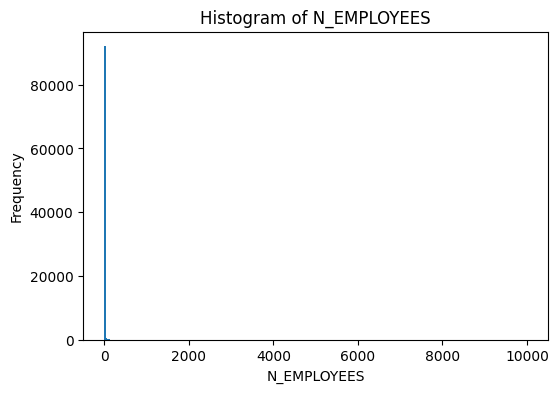

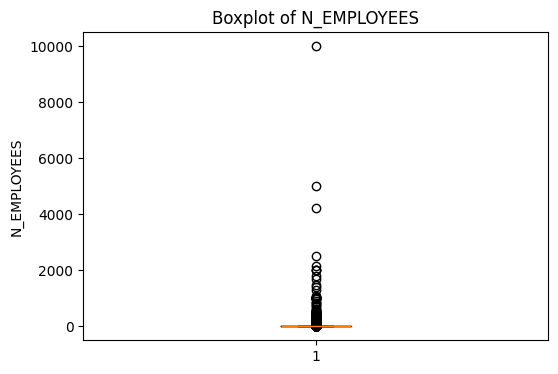

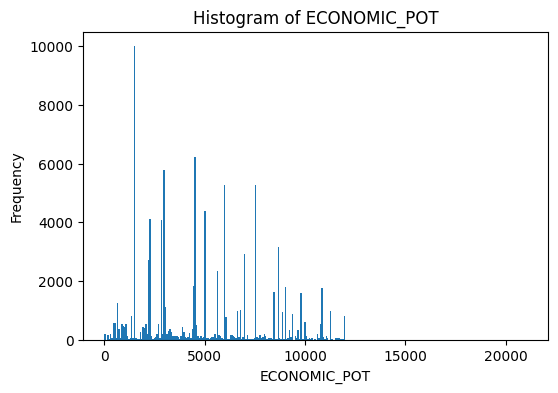

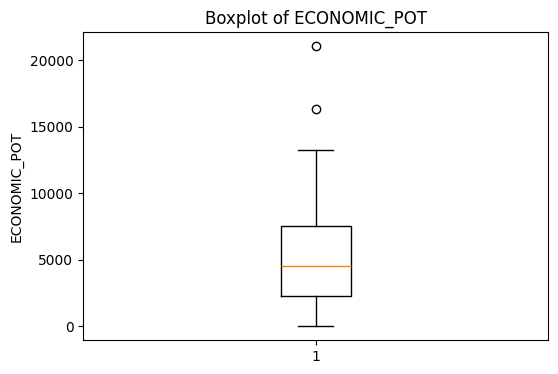

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["N_EMPLOYEES", "ECONOMIC_POT"]
for col in cols:
    s = df[col].dropna()

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(s, bins=300)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,4))
    plt.boxplot(s, vert=True)
    plt.ylabel(col)
    plt.title(f"Boxplot of {col}")
    plt.show()

removing outliers otherwise is impossible to plot histograms.

In [79]:
Q1a = df["N_EMPLOYEES"].quantile(0.25)
Q3a = df["N_EMPLOYEES"].quantile(0.75)
Q1b = df["ECONOMIC_POT"].quantile(0.25)
Q3b = df["ECONOMIC_POT"].quantile(0.75)

IQRa = Q3a - Q1a
IQRb = Q3b - Q1b

lowera = Q1a - 1.5 * IQRa
uppera = Q3a + 1.5 * IQRa
lowerb = Q1b - 1.5 * IQRb
upperb = Q3b + 1.5 * IQRb

df_clean = df[(df["ECONOMIC_POT"] >= lowerb) & (df["ECONOMIC_POT"] <= upperb)]
df_clean = df[(df["N_EMPLOYEES"] >= lowera) & (df["N_EMPLOYEES"] <= uppera)]

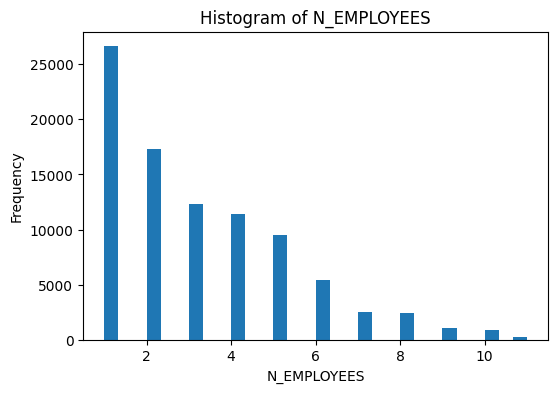

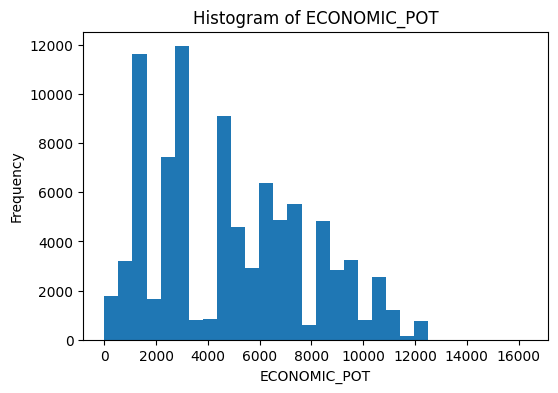

In [80]:
for col in cols:
    s = df_clean[col].dropna()

    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(s, bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.show()

#eE
Interpretation

# Categorical columns

For REGION, TRADE SECTOR, ECO_POT_CLASS, RISK_CAT, ask:

How many categories are there?

Which categories dominate?

Are some rare?


 REGION


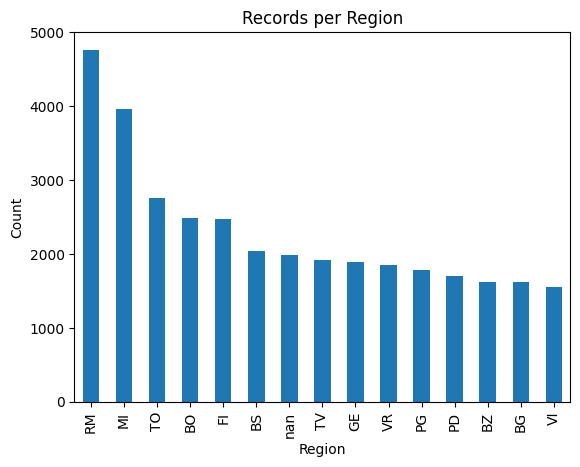

In [56]:

import matplotlib.pyplot as plt
print("\n", "REGION")
rgions = df["REGION"].value_counts(dropna=False).head(15)

rgions.plot.bar()

plt.xlabel("Region")
plt.ylabel("Count")
plt.title("Records per Region")

plt.show()


 TRADE SECTOR


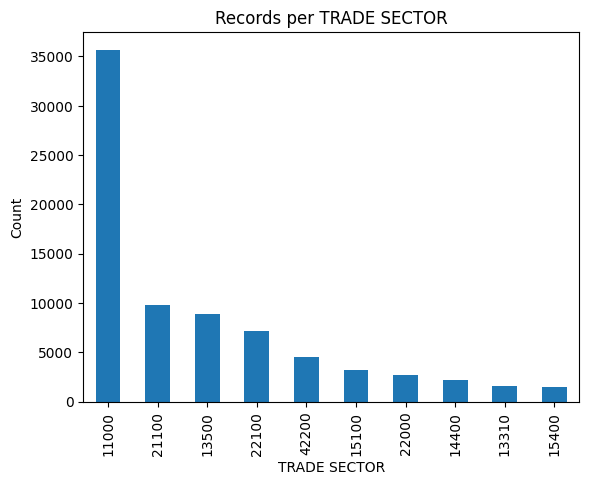

In [57]:
import matplotlib.pyplot as plt
print("\n", "TRADE SECTOR")
rgions = df["TRADE SECTOR"].value_counts(dropna=False).head(10)

rgions.plot.bar()

plt.xlabel("TRADE SECTOR")
plt.ylabel("Count")
plt.title("Records per TRADE SECTOR")

plt.show()

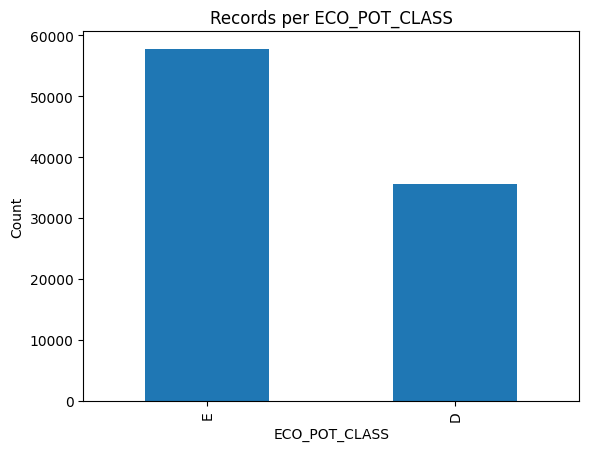

In [58]:

rgions = df["ECO_POT_CLASS"].value_counts(dropna=False).head(10)
rgions.plot.bar()

plt.xlabel("ECO_POT_CLASS")
plt.ylabel("Count")
plt.title("Records per ECO_POT_CLASS")

plt.show()

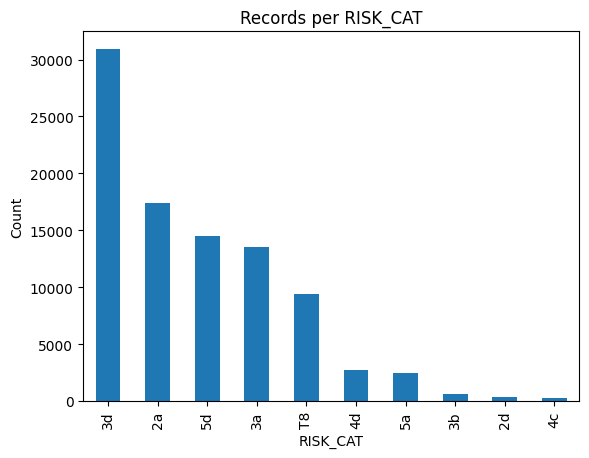

In [59]:
rgions = df["RISK_CAT"].value_counts(dropna=False).head(10)
rgions.plot.bar()

plt.xlabel("RISK_CAT")
plt.ylabel("Count")
plt.title("Records per RISK_CAT")

plt.show()

# Explore relationships between variables

Numeric vs categorical

Does ECONOMIC_POT differ by REGION?

In [82]:
region_stats = (
    df.groupby("REGION")["ECONOMIC_POT"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("median", ascending=False)
)

print(region_stats)

        count         mean   median     min       max
REGION                                               
CA        797  6523.428494  6728.89    0.00  11996.62
RG        154  6345.907532  6688.76  340.63  11996.62
AG        312  6181.421090  6648.63  453.93  11996.62
VS        167  6101.971497  6100.00    0.00  11996.62
OR        208  5922.004231  6100.00  453.93  11996.62
...       ...          ...      ...     ...       ...
74          1     0.000000     0.00    0.00      0.00
75          1     0.000000     0.00    0.00      0.00
06          3     0.000000     0.00    0.00      0.00
05          1     0.000000     0.00    0.00      0.00
03          2     0.000000     0.00    0.00      0.00

[121 rows x 5 columns]


<Figure size 9000x500 with 0 Axes>

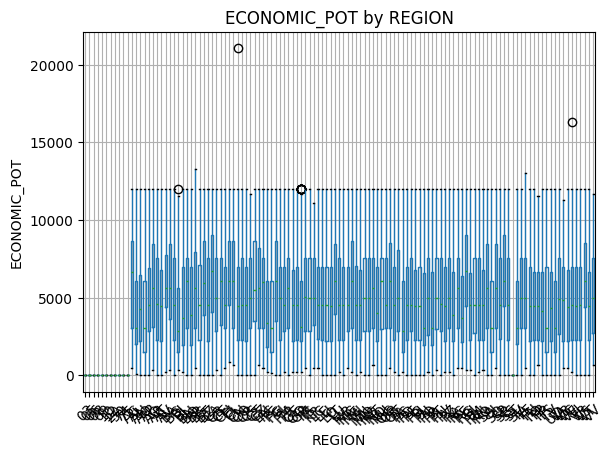

In [87]:
plt.figure(figsize=(90, 5))
df.boxplot(column="ECONOMIC_POT", by="REGION", rot=45)
plt.title("ECONOMIC_POT by REGION")
plt.suptitle("")
plt.xlabel("REGION")
plt.ylabel("ECONOMIC_POT")
plt.show()

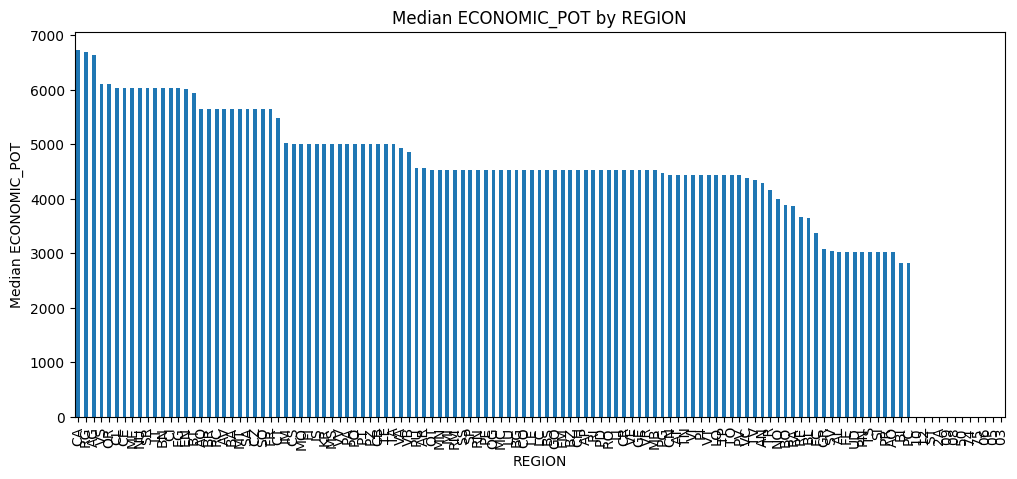

In [84]:
region_median = (
    df.groupby("REGION")["ECONOMIC_POT"]
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
region_median.plot(kind="bar")
plt.title("Median ECONOMIC_POT by REGION")
plt.ylabel("Median ECONOMIC_POT")
plt.show()

Does N_EMPLOYEES differ by ECO_POT_CLASS?

In [88]:
eco_class_stats = (
    df.groupby("ECO_POT_CLASS")["N_EMPLOYEES"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_index()
)

print(eco_class_stats)

               count      mean  median  min    max
ECO_POT_CLASS                                     
D              35532  8.774288     5.0    1  10000
E              57725  3.369008     2.0    1   2021


<Figure size 1000x500 with 0 Axes>

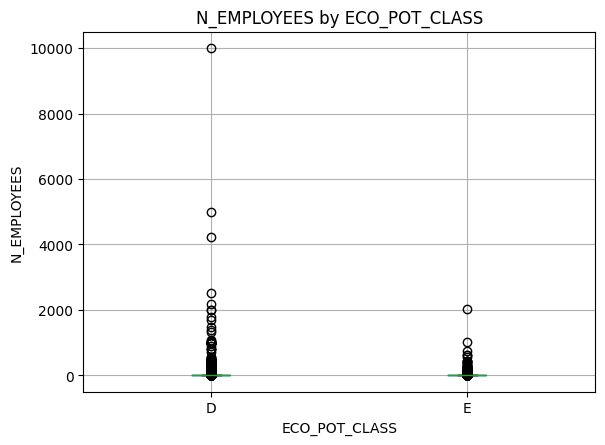

In [90]:
plt.figure(figsize=(10, 5))
df.boxplot(column="N_EMPLOYEES", by="ECO_POT_CLASS")
plt.title("N_EMPLOYEES by ECO_POT_CLASS")
plt.suptitle("")
plt.xlabel("ECO_POT_CLASS")
plt.ylabel("N_EMPLOYEES")
plt.show()

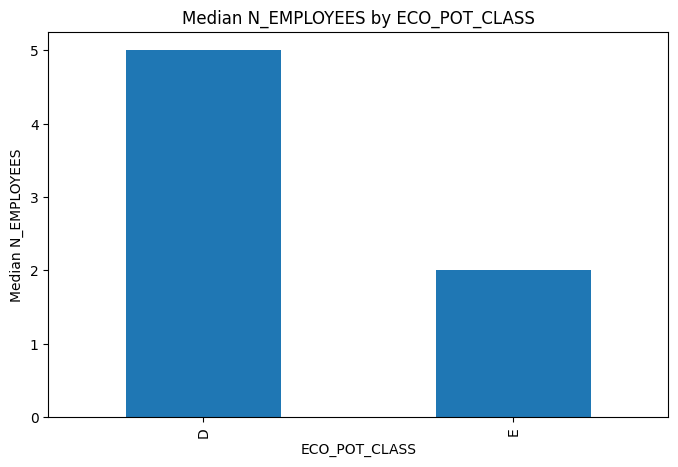

In [91]:
eco_class_median = (
    df.groupby("ECO_POT_CLASS")["N_EMPLOYEES"]
      .median()
      .sort_index()
)

plt.figure(figsize=(8, 5))
eco_class_median.plot(kind="bar")
plt.title("Median N_EMPLOYEES by ECO_POT_CLASS")
plt.ylabel("Median N_EMPLOYEES")
plt.show()

Which TRADE SECTORs have the highest economic potential?

In [92]:
sector_stats = (
    df.groupby("TRADE SECTOR")["ECONOMIC_POT"]
      .agg(["count", "mean", "median"])
      .sort_values("median", ascending=False)
)

print(sector_stats.head(15))

              count          mean     median
TRADE SECTOR                                
21720             1  10969.660000  10969.660
32600            14   9099.357143  10072.000
32200            42   7718.142857  10000.000
32400             9   9523.666667  10000.000
33200            17   8731.470588  10000.000
32700            46   7291.152174   9499.500
13300            46   7135.908261   9155.330
34140             4   9291.500000   9024.000
32100           132   7171.954545   9000.000
33400            11   8276.636364   8761.000
33130           195   6870.461538   8661.000
34110           119   7769.689076   8489.000
37300            11   7677.084545   8457.000
33300             8   6865.125000   8351.000
41500            50   6435.447400   8302.395


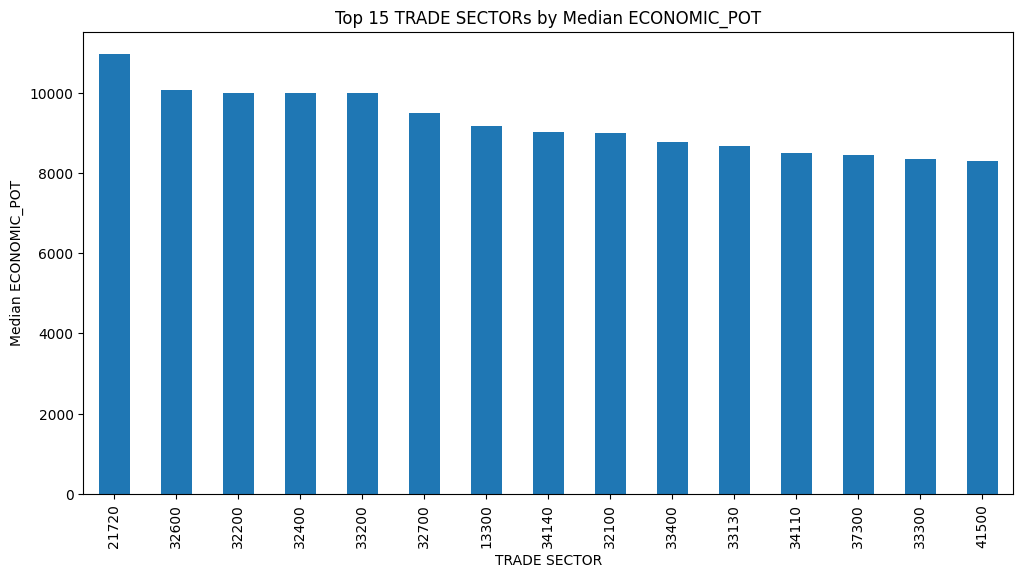

In [93]:
top_sector_median = (
    df.groupby("TRADE SECTOR")["ECONOMIC_POT"]
      .median()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 6))
top_sector_median.plot(kind="bar")
plt.title("Top 15 TRADE SECTORs by Median ECONOMIC_POT")
plt.ylabel("Median ECONOMIC_POT")
plt.show()

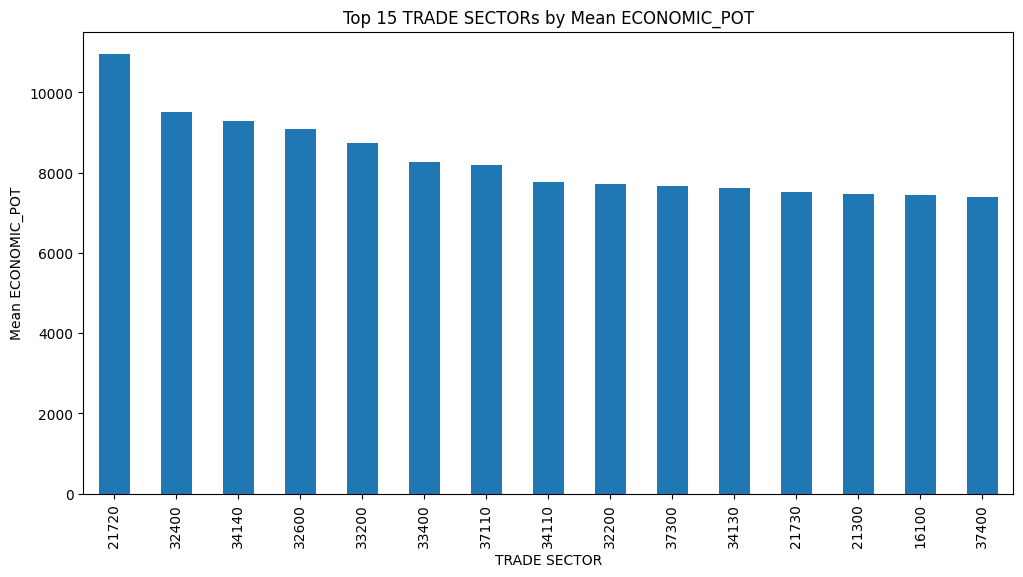

In [94]:
top_sector_mean = (
    df.groupby("TRADE SECTOR")["ECONOMIC_POT"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 6))
top_sector_mean.plot(kind="bar")
plt.title("Top 15 TRADE SECTORs by Mean ECONOMIC_POT")
plt.ylabel("Mean ECONOMIC_POT")
plt.show()

Numeric vs numeric

Do bigger companies also have higher ECONOMIC_POT?

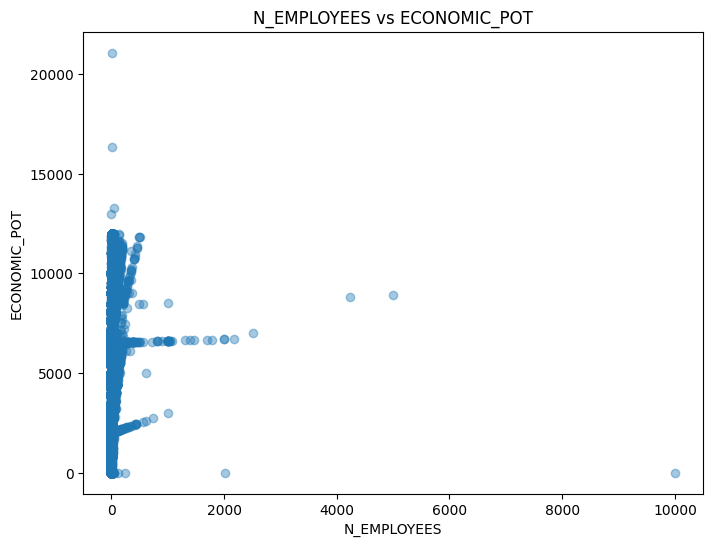

In [95]:
plt.figure(figsize=(8, 6))
plt.scatter(df["N_EMPLOYEES"], df["ECONOMIC_POT"], alpha=0.4)
plt.xlabel("N_EMPLOYEES")
plt.ylabel("ECONOMIC_POT")
plt.title("N_EMPLOYEES vs ECONOMIC_POT")
plt.show()

In [96]:
corr = df[["N_EMPLOYEES", "ECONOMIC_POT"]].corr()
print(corr)

              N_EMPLOYEES  ECONOMIC_POT
N_EMPLOYEES      1.000000      0.051634
ECONOMIC_POT     0.051634      1.000000


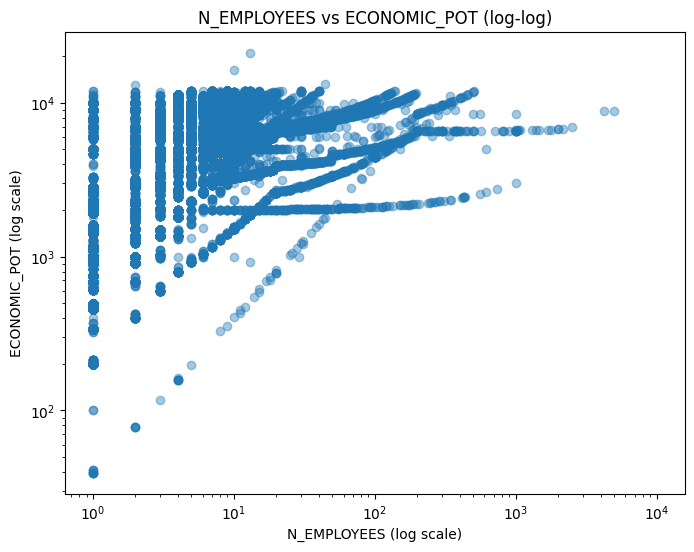

In [97]:
plt.figure(figsize=(8, 6))
plt.scatter(df["N_EMPLOYEES"], df["ECONOMIC_POT"], alpha=0.4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N_EMPLOYEES (log scale)")
plt.ylabel("ECONOMIC_POT (log scale)")
plt.title("N_EMPLOYEES vs ECONOMIC_POT (log-log)")
plt.show()